# T0 v. Plasmid Analysis

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [106]:
ABE_master_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/ABE_master_LFC_table.csv')
CBE_master_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/CBE_master_LFC_table.csv')

ABE_editing_master = pd.read_csv('../../screening_data/04_editing/ABE_editing_master.csv')
CBE_editing_master = pd.read_csv('../../screening_data/04_editing/CBE_editing_master.csv')

In [108]:
def KLIFS_annotator(comb):
    KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

    genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

    k_holder = []
    for gene in genes:
        k = list(KLIFS[gene])
        k_holder.append(k)

    klifs_dict = dict(zip(genes, k_holder))

    in_pocket_hg = []
    KLIFS_idx_hg = []
    in_pocket_sav = []
    KLIFS_idx_sav = []

    for i, val in comb.iterrows():
        g = val['Gene']
        l = klifs_dict[g]
        if val['Top_HGVSp_Codon'] in l:
            in_pocket_hg.append(True)
            KLIFS_idx_hg.append(l.index(val['Top_HGVSp_Codon'])+1)

        if val['Top_HGVSp_Codon'] not in l:
            in_pocket_hg.append(False)
            KLIFS_idx_hg.append(None)

        if val['Codon']!='WT':
            if int(val['Codon']) in l:
                in_pocket_sav.append(True)
                KLIFS_idx_sav.append(l.index(int(val['Codon']))+1)

            if int(val['Codon']) not in l:
                in_pocket_sav.append(False)
                KLIFS_idx_sav.append(None)
        else:
            in_pocket_sav.append(False)
            KLIFS_idx_sav.append(None)

    comb['ATP_binding_pocket_top'] = in_pocket_hg
    comb['KLIFS_index_top'] = KLIFS_idx_hg
    comb['ATP_binding_pocket_SAV'] = in_pocket_sav
    comb['KLIFS_index_SAV'] = KLIFS_idx_sav

    return comb

In [109]:
ABE_editing_master = KLIFS_annotator(ABE_editing_master)
CBE_editing_master = KLIFS_annotator(CBE_editing_master)


# Assess depletion in ATP binding pocket

In [593]:
c1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]
cbe_merge = pd.merge(CBE_editing_master, c1, on='gRNA_id')


a1 = ABE_master_LFC[(ABE_master_LFC['Base_Value']=='Plasmid') & (ABE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]
abe_merge = pd.merge(ABE_editing_master, a1, on='gRNA_id')

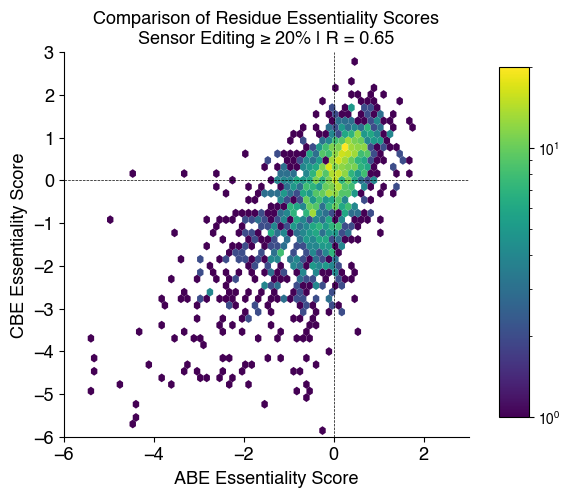

In [678]:
#comparison of ABE and CBE residue essentiality
min_edit = 20

cs = cbe_merge[(cbe_merge['%Reads']>=min_edit) & (cbe_merge['Mutation_Class_SAV']=='Missense')]
aaa = abe_merge[(abe_merge['%Reads']>=min_edit) & (cbe_merge['Mutation_Class_SAV']=='Missense')]


cbe_avg = cs[['Gene', 'Codon', 'LFC_median_T0_Plasmid',]].groupby(by=['Gene', 'Codon']).mean().reset_index().rename(columns = {'LFC_median_T0_Plasmid':'CBE_essentiality'})
abe_avg = aaa[['Gene', 'Codon', 'LFC_median_T0_Plasmid',]].groupby(by=['Gene', 'Codon']).mean().reset_index().rename(columns = {'LFC_median_T0_Plasmid':'ABE_essentiality'})

md = pd.merge(cbe_avg, abe_avg, on=['Gene', 'Codon'])
x,y = md['ABE_essentiality'], md['CBE_essentiality']
fig, ax = plt.subplots(figsize=(6,5))
ax.set_xlim(-6,3)
ax.set_ylim(-6,3)
im = ax.hexbin(x,y, bins='log', linewidths=0, cmap='viridis', gridsize=50)
ax.axvline(0, linestyle='dashed', color='black', linewidth=.5)
ax.axhline(0, linestyle='dashed', color='black', linewidth=.5)

ax.spines[['top', 'right']].set_visible(False)

ax.set_title(f'Comparison of Residue Essentiality Scores\nSensor Editing ≥ 20% | R = {np.round(scipy.stats.pearsonr(x,y).statistic,2)}', fontsize=13)

ax.set_ylabel('CBE Essentiality Score', fontsize=13)
ax.set_xlabel('ABE Essentiality Score', fontsize=13)

ax.tick_params(axis='both', which='major', labelsize=13)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)


#fig.savefig('../../figures/ABE_CBE_essent_comp.pdf', transparent=True)

In [417]:
min_edit = 20
#identify missense edits in atp binding pocket above X% efficiency
cbe_atp = list(cbe_merge[(cbe_merge['%Reads']>=min_edit) & (cbe_merge['ATP_binding_pocket_SAV']==True) & (cbe_merge['Mutation_Class_SAV']=='Missense')]['gRNA_id'])
abe_atp = list(abe_merge[(abe_merge['%Reads']>=min_edit) & (abe_merge['ATP_binding_pocket_SAV']==True) & (abe_merge['Mutation_Class_SAV']=='Missense')]['gRNA_id'])

cbe_merge.loc[cbe_merge['gRNA_id'].isin(cbe_atp), 'ATP Binding Pocket'] = True
cbe_merge.loc[~cbe_merge['gRNA_id'].isin(cbe_atp), 'ATP Binding Pocket'] = False

abe_merge.loc[abe_merge['gRNA_id'].isin(cbe_atp), 'ATP Binding Pocket'] = True
abe_merge.loc[~abe_merge['gRNA_id'].isin(cbe_atp), 'ATP Binding Pocket'] = False

abe_subset = abe_merge.drop_duplicates(subset='gRNA_id')
cbe_subset = cbe_merge.drop_duplicates(subset='gRNA_id')

<Axes: xlabel='Screen_ID', ylabel='LFC_median_T0_Plasmid'>

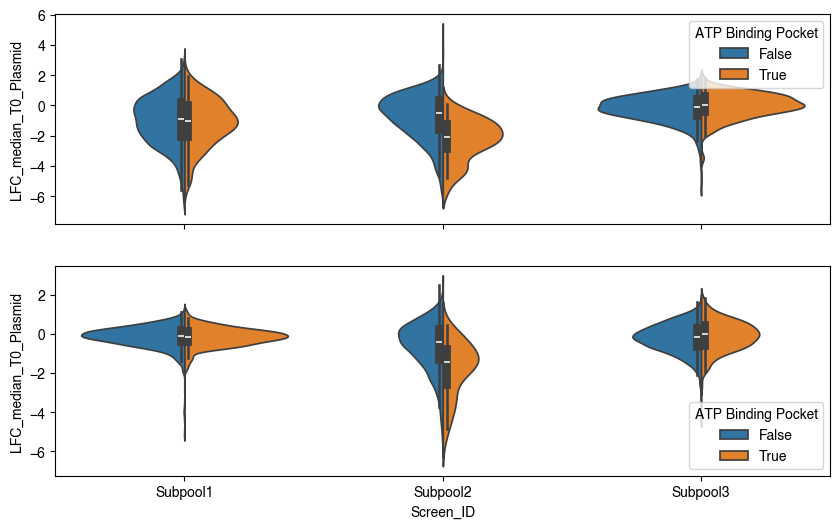

In [419]:
fig, ax = plt.subplots(2,1,figsize=(10,6), sharex=True)

sns.violinplot(data=cbe_subset, x='Screen_ID', y='LFC_median_T0_Plasmid', hue='ATP Binding Pocket', ax=ax[0], split=True)
sns.violinplot(data=abe_subset, x='Screen_ID', y='LFC_median_T0_Plasmid', hue='ATP Binding Pocket', ax=ax[1], split=True)

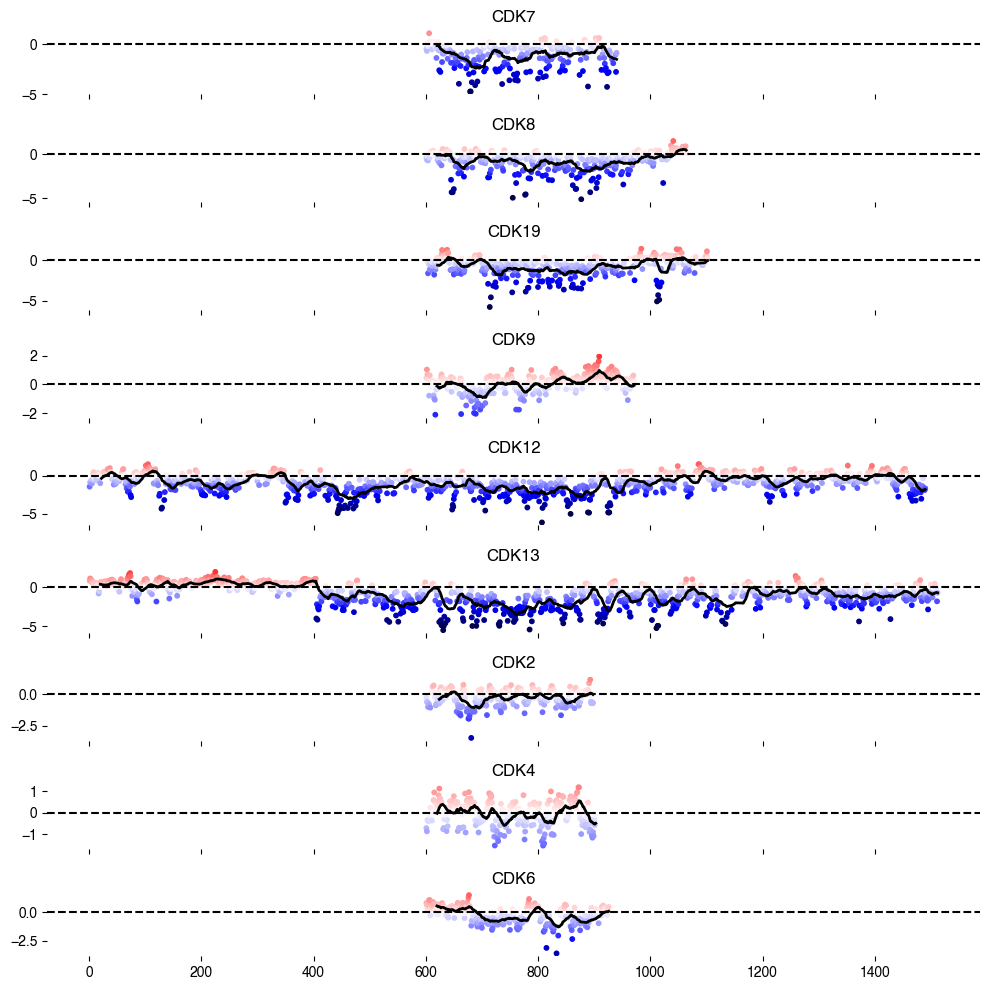

In [ ]:
min_edit = 20

cs = cbe_merge[cbe_merge['%Reads']>=min_edit]
aaa = abe_merge[abe_merge['%Reads']>=min_edit]
cs = pd.concat((cs, aaa))
cs['counter'] = 1
cbe_meaned = cs[['Gene', 'Codon', 'LFC_median_T0_Plasmid', 'counter']].groupby(by=['Gene', 'Codon']).mean().reset_index()


fig, ax = plt.subplots(9,1,figsize=(10,10), sharex=True, sharey=False)

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
for i,gene in enumerate(genes):

    c2 = cbe_meaned[cbe_meaned['Gene']==gene]

    c2 = c2[c2['Codon']!='WT']
    c2['Codon'] = [int(i) for i in c2['Codon']]

    c2 = c2.sort_values(by='Codon')

    if gene not in ['CDK12', 'CDK13']:

        #ax[i].plot(np.array(c2['Codon'])+600, c2['LFC_median_T0_Plasmid'], linewidth=3)

        window = 20  # number of points to average
        y_smooth = np.convolve(np.array(c2['LFC_median_T0_Plasmid']), np.ones(window)/window, mode='valid')

        ax[i].plot(np.array(c2['Codon'])[window-1:]+600, y_smooth, linewidth=2, color='black')


        ax[i].scatter(np.array(c2['Codon'])+600, c2['LFC_median_T0_Plasmid'], cmap='seismic',c=np.array(c2['LFC_median_T0_Plasmid']),vmin=-5, vmax=5, s=10)



    else:
        window = 20  # number of points to average
        y_smooth = np.convolve(np.array(c2['LFC_median_T0_Plasmid']), np.ones(window)/window, mode='valid')

        ax[i].plot(np.array(c2['Codon'])[window-1:], y_smooth, linewidth=2, color='black')

        ax[i].scatter(c2['Codon'], c2['LFC_median_T0_Plasmid'], cmap='seismic',c=np.array(c2['LFC_median_T0_Plasmid']),vmin=-5, vmax=5, s=10)


    ax[i].axhline(0, linestyle='dashed', color='black')
    ax[i].set_title(f'{gene}', fontsize=12)

    ax[i].spines[['top','right','left', 'bottom']].set_visible(False)

fig.tight_layout()

In [618]:
def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

In [ ]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

start_klifs = []
for gene in genes:
    numbers = list(KLIFS[gene].dropna())

    r = find_ranges(numbers)
    for k in r:
        ax[a].axvspan(k[0],k[1], alpha=.2)
start_dict = dict(zip(genes, start_klifs))
start_dict

{'CDK7': 16.0,
 'CDK8': 25.0,
 'CDK19': 25.0,
 'CDK9': 23.0,
 'CDK12': 731.0,
 'CDK13': 709.0,
 'CDK2': 8.0,
 'CDK4': 10.0,
 'CDK6': 17.0}

In [630]:
start_dict_transform = dict(zip(genes, [max(start_dict.values())-i for i in start_dict.values()]))
start_dict_transform

{'CDK7': 715.0,
 'CDK8': 706.0,
 'CDK19': 706.0,
 'CDK9': 708.0,
 'CDK12': 0.0,
 'CDK13': 22.0,
 'CDK2': 723.0,
 'CDK4': 721.0,
 'CDK6': 714.0}

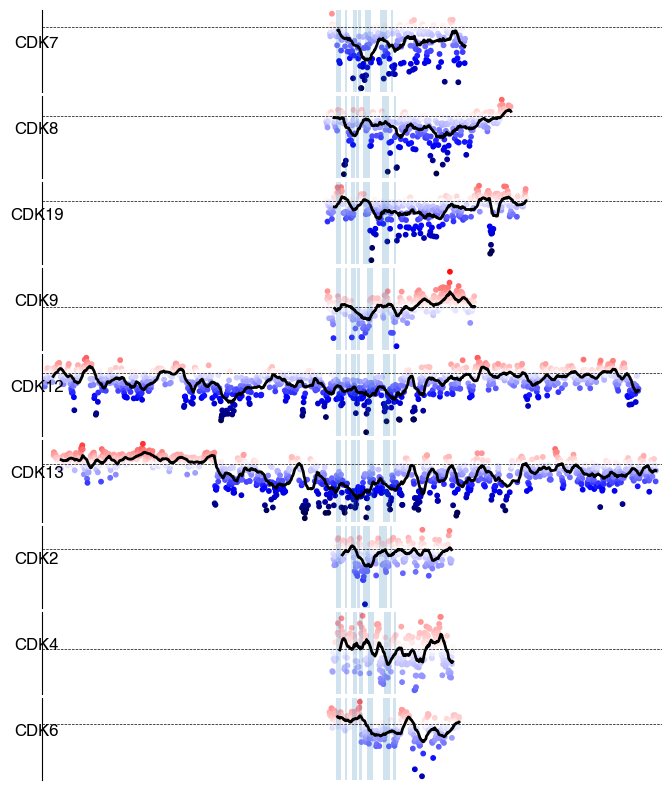

In [680]:
min_edit = 20

cs = cbe_merge[(cbe_merge['%Reads']>=min_edit) & (cbe_merge['Mutation_Class_SAV']=='Missense')]
aaa = abe_merge[(abe_merge['%Reads']>=min_edit) & (cbe_merge['Mutation_Class_SAV']=='Missense')]

cs = pd.concat((cs, aaa))
cs['counter'] = 1
cbe_meaned = cs[['Gene', 'Codon', 'LFC_median_T0_Plasmid', 'counter']].groupby(by=['Gene', 'Codon']).mean().reset_index()


fig, ax = plt.subplots(9,1,figsize=(8,10), sharex=True, sharey=False)

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
for i,gene in enumerate(genes):

    c2 = cbe_meaned[cbe_meaned['Gene']==gene]

    c2 = c2[c2['Codon']!='WT']
    c2['Codon'] = [int(i) for i in c2['Codon']]

    c2 = c2.sort_values(by='Codon')

    transform_amt = start_dict_transform[gene]

        #ax[i].plot(np.array(c2['Codon'])+600, c2['LFC_median_T0_Plasmid'], linewidth=3)

    window = 20  # number of points to average
    y_smooth = np.convolve(np.array(c2['LFC_median_T0_Plasmid']), np.ones(window)/window, mode='valid')

    ax[i].plot(np.array(c2['Codon'])[window-1:]+transform_amt, y_smooth, linewidth=2, color='black')


    ax[i].scatter(np.array(c2['Codon'])+transform_amt, c2['LFC_median_T0_Plasmid'], cmap='seismic',c=np.array(c2['LFC_median_T0_Plasmid']),vmin=-5, vmax=5, s=10)


    numbers = list(KLIFS[gene].dropna())
    r = find_ranges(numbers)
    for k in r:
        ax[i].axvspan(k[0]+transform_amt,k[1]+transform_amt, alpha=.2)


    ax[i].axhline(0, linestyle='dashed', color='black', linewidth=.5)
    ax[i].set_ylabel(f'{gene}', rotation=0, fontsize=12)
    ax[i].set_xlim(-5,1550)
    
    ax[i].set_xticks([])  # Removes x-axis ticks and labels
    ax[i].set_yticks([])

    ax[i].spines[['top','right', 'bottom']].set_visible(False)

#fig.tight_layout()

fig.subplots_adjust(hspace=0.05)
#fig.savefig('../../figures/res_essentiality_ABE_CBE_combined_20_min_edit_SAV.pdf', transparent=True)


In [683]:
genes

['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

In [685]:

for gene in genes:
    c2 = cbe_meaned[cbe_meaned['Gene']==gene]

    c2 = c2[c2['Codon']!='WT']
    c2['Codon'] = [int(i) for i in c2['Codon']]
    c2 = c2.sort_values(by='Codon')

    #add in random mutation
    em = pd.concat((ABE_editing_master, CBE_editing_master))
    cdk2_sample_edits = em[(em['Gene']==gene) & (em['Mutation_Class_SAV']=='Missense')].drop_duplicates(subset='Codon')

    cdk2_sample_edits = cdk2_sample_edits[['Codon', 'HGVSp']]
    cdk2_sample_edits['Codon'] = [int(i) for i in cdk2_sample_edits['Codon']]
    coloring = pd.merge(c2, cdk2_sample_edits, on='Codon')

    coloring = coloring[['HGVSp', 'Codon', 'LFC_median_T0_Plasmid']]

    coloring['HGVSp'] = [f'p.({i})' for i in coloring['HGVSp']]
    coloring['type'] = 'missense'


    coloring['wildtype'] = [i[3] for i in coloring['HGVSp']]
    coloring['mutation'] = [i[-2] for i in coloring['HGVSp']]

    coloring = coloring.rename(columns={'HGVSp':'variants', 'Codon':'position', 'LFC_median_T0_Plasmid':'essentiality'})
    cols = ['variants','wildtype','position','mutation','type','essentiality']

    coloring = coloring[cols]
    #coloring2 = coloring
    coloring.to_csv(f'../../notebooks/10_PyMOL/{gene}_scores.csv', index=False)

In [570]:
coloring

,variants,wildtype,position,mutation,type,essentiality
0,p.(M1I),M,1,I,missense,-0.180682
1,p.(E2Q),E,2,Q,missense,-0.266631
2,p.(N3K),N,3,K,missense,-1.579092
3,p.(F4L),F,4,L,missense,-1.413988
4,p.(Q5E),Q,5,E,missense,-0.803228
...,...,...,...,...,...,...
272,p.(P294L),P,294,L,missense,0.208067
273,p.(H295Q),H,295,Q,missense,-0.469995
274,p.(L296V),L,296,V,missense,-0.585310
275,p.(R297D),R,297,D,missense,-0.649661


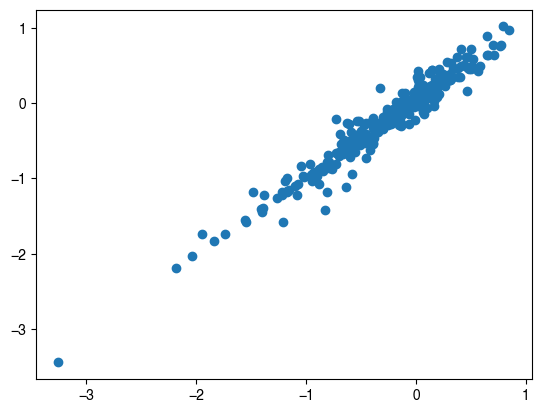

In [571]:
plt.scatter(coloring2['essentiality'], coloring['essentiality'])

In [ ]:
cdk2_sample_edits = CBE_editing_master[(CBE_editing_master['Gene']=='CDK2') & (CBE_editing_master['Mutation_Class_SAV']=='Missense')].drop_duplicates(subset='Codon')

cdk2_sample_edits = cdk2_sample_edits[['Codon', 'HGVSp']]

,Codon,HGVSp
64849,5,Q5E
64851,6,K6L
64853,4,F4L
64857,3,N3K
64859,2,E2Q
...,...,...
69323,250,K250A
69443,266,M266R
69462,267,L267Q
69488,269,Y269H


open csv file
mutationscores structure #7/A allowMismatches True mutationSet CDK2_scores
mutationscores define ess fromScoreName essentiality above -10 combine sum mutationSet CDK2_scores
color byattribute r:ess #7/A target sabc palette -1,blue:0,white:1,red noValueColor grey

In [400]:
min_edit = 20
klifs_1 = list(range(20,31))
#identify missense edits in atp binding pocket above X% efficiency
cbe_atp = list(cbe_merge[(cbe_merge['%Reads']>=min_edit) & (cbe_merge['ATP_binding_pocket_SAV']==True) & (cbe_merge['Mutation_Class_SAV']=='Missense') & (cbe_merge['KLIFS_index_SAV'].isin(klifs_1))]['gRNA_id'])
abe_atp = list(abe_merge[(abe_merge['%Reads']>=min_edit) & (abe_merge['ATP_binding_pocket_SAV']==True) & (abe_merge['Mutation_Class_SAV']=='Missense') & (abe_merge['KLIFS_index_SAV'].isin(klifs_1))]['gRNA_id'])

cbe_merge.loc[cbe_merge['gRNA_id'].isin(cbe_atp), 'alphaC Helix'] = True
cbe_merge.loc[~cbe_merge['gRNA_id'].isin(cbe_atp), 'alphaC Helix'] = False

abe_merge.loc[abe_merge['gRNA_id'].isin(cbe_atp), 'alphaC Helix'] = True
abe_merge.loc[~abe_merge['gRNA_id'].isin(cbe_atp), 'alphaC Helix'] = False

abe_subset = abe_merge.drop_duplicates(subset='gRNA_id')
cbe_subset = cbe_merge.drop_duplicates(subset='gRNA_id')

<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

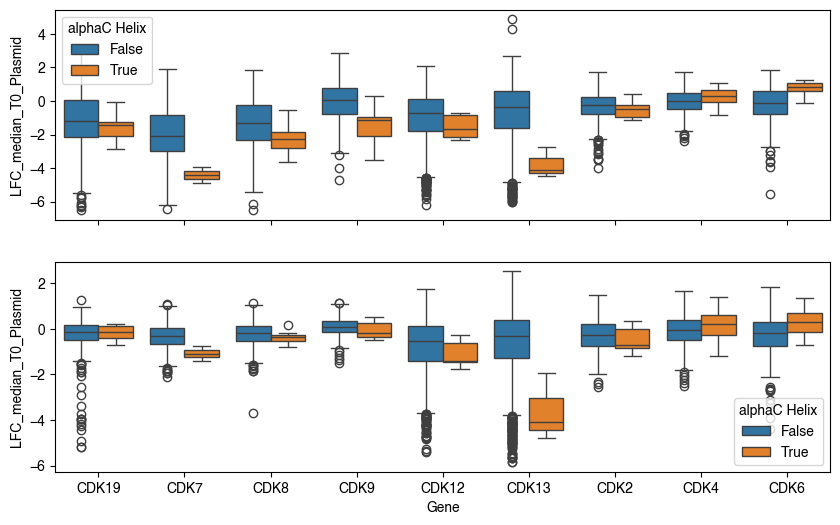

In [401]:
fig, ax = plt.subplots(2,1,figsize=(10,6), sharex=True)

sns.boxplot(data=cbe_subset, x='Gene', y='LFC_median_T0_Plasmid', hue='alphaC Helix', ax=ax[0])
sns.boxplot(data=abe_subset, x='Gene', y='LFC_median_T0_Plasmid', hue='alphaC Helix', ax=ax[1])

In [396]:
for gene in ['CDK8', 'CDK19', 'CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(cbe_subset[(cbe_subset['Gene']==gene) & (cbe_subset['alphaC Helix']==True)]['LFC_median_T0_Plasmid'])
    y = list(cbe_subset[(cbe_subset['Gene']==gene) & (cbe_subset['alphaC Helix']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

for gene in ['CDK8', 'CDK19', 'CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(abe_subset[(abe_subset['Gene']==gene) & (abe_subset['alphaC Helix']==True)]['LFC_median_T0_Plasmid'])
    y = list(abe_subset[(abe_subset['Gene']==gene) & (abe_subset['alphaC Helix']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

CDK8
Ttest_indResult(statistic=-1.5760084851631697, pvalue=0.11553229398219297)
CDK19
Ttest_indResult(statistic=-0.6583567098846226, pvalue=0.5105260314916252)
CDK7
Ttest_indResult(statistic=-2.268898572940197, pvalue=0.023776313462881733)
CDK9
Ttest_indResult(statistic=-4.125518592198891, pvalue=4.152700175759289e-05)
CDK12
Ttest_indResult(statistic=-0.9863373407315832, pvalue=0.32407586669958244)
CDK13
Ttest_indResult(statistic=-3.361563018095424, pvalue=0.0007876968292102771)
CDK2
Ttest_indResult(statistic=-0.6175513077757557, pvalue=0.5371708701194274)
CDK4
Ttest_indResult(statistic=1.56405940869735, pvalue=0.11840160691972729)
CDK6
Ttest_indResult(statistic=4.519351646569807, pvalue=7.747102474645201e-06)
CDK8
Ttest_indResult(statistic=-0.7998170694151391, pvalue=0.4241221355573985)
CDK19
Ttest_indResult(statistic=0.21060547521130252, pvalue=0.8332566048907699)
CDK7
Ttest_indResult(statistic=-1.9899189399041404, pvalue=0.04724168813809498)
CDK9
Ttest_indResult(statistic=-1.1662830

In [383]:
for gene in ['CDK8', 'CDK19', 'CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(cbe_subset[(cbe_subset['Gene']==gene) & (cbe_subset['ATP Binding Pocket']==True)]['LFC_median_T0_Plasmid'])
    y = list(cbe_subset[(cbe_subset['Gene']==gene) & (cbe_subset['ATP Binding Pocket']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

for gene in ['CDK8', 'CDK19', 'CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(abe_subset[(abe_subset['Gene']==gene) & (abe_subset['ATP Binding Pocket']==True)]['LFC_median_T0_Plasmid'])
    y = list(abe_subset[(abe_subset['Gene']==gene) & (abe_subset['ATP Binding Pocket']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

CDK8
Ttest_indResult(statistic=-0.27029514747982003, pvalue=0.7870228573845462)
CDK19
Ttest_indResult(statistic=0.8992040085642206, pvalue=0.3688541011100739)
CDK7
Ttest_indResult(statistic=-2.5286188526639273, pvalue=0.01181305941050761)
CDK9
Ttest_indResult(statistic=-3.232134578785266, pvalue=0.0012873831687296997)
CDK12
Ttest_indResult(statistic=-5.653239104772406, pvalue=1.7785638177395687e-08)
CDK13
Ttest_indResult(statistic=-6.3081710035442455, pvalue=3.375530354996969e-10)
CDK2
Ttest_indResult(statistic=-0.3723150856074857, pvalue=0.709826444679118)
CDK4
Ttest_indResult(statistic=0.8313577661858921, pvalue=0.4061466399062357)
CDK6
Ttest_indResult(statistic=3.8647108786614717, pvalue=0.00012584368978605683)
CDK8
Ttest_indResult(statistic=-1.1117598550541323, pvalue=0.2666709466280578)
CDK19
Ttest_indResult(statistic=1.091340897574388, pvalue=0.2754994742269341)
CDK7
Ttest_indResult(statistic=-1.683095208693279, pvalue=0.09309277563831143)
CDK9
Ttest_indResult(statistic=-0.457881

In [385]:
#then look at resistance variants vs. others in the ATP binding pocket

#need to select these for each condition
LFC_cutoff = 1
FDR_cutoff = .1
min_edit = 20

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
subpools = ['SY-5609', 'Subpool1', 'Subpool1', 'Subpool1', 'Subpool2', 'Subpool2', 'Subpool3', 'Subpool3', 'Subpool3']
drugs = [['SY-5609_10nM', 'SY-5609_100nM'],
         ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM'],
         ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM'],
         ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM'],
         ['HQ461', 'BSJ-4-116', 'CDK12-IN-2'],
         ['HQ461', 'BSJ-4-116', 'CDK12-IN-2'],
         ['INX', 'TAGTO'],
         ['PALBO', 'ABEMA', 'RIBO', 'ATIRMO',],
         ['PALBO', 'ABEMA', 'RIBO', 'ATIRMO',]]

cbe_hit_list = []
abe_hit_list = []
for i, val in enumerate(genes):

    subset_cbe = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='DMSO') & (CBE_master_LFC['Screen_ID']==subpools[i])]

    merged = pd.merge(CBE_editing_master, subset_cbe, on='gRNA_id')

    merged = merged[merged['Gene']==val]

    drug_list = drugs[i]
    hits = []
    for drug in drug_list:

        l = merged[(merged[f'LFC_median_{drug}_DMSO']>=LFC_cutoff) & (merged[f'FDR_{drug}_DMSO']<FDR_cutoff) & (merged['ATP_binding_pocket_SAV']==True) & (merged['%Reads']>=min_edit) & (merged['Mutation_Class_SAV']=='Missense')]
        for k in list(l['gRNA_id']):
            hits.append(k)


    cbe_hit_list.append(hits)



In [386]:
#identify missense edits in atp binding pocket above X% efficiency
cbe_atp = cbe_merge[(cbe_merge['%Reads']>=min_edit) & (cbe_merge['ATP_binding_pocket_SAV']==True) & (cbe_merge['Mutation_Class_SAV']=='Missense')]

flat_cbe_hits = np.unique([item for sublist in cbe_hit_list for item in sublist])

cbe_atp.loc[cbe_atp['gRNA_id'].isin(flat_cbe_hits), 'Resistance Variant'] = True
cbe_atp.loc[~cbe_atp['gRNA_id'].isin(flat_cbe_hits), 'Resistance Variant'] = False

CDK7
Ttest_indResult(statistic=3.700444700471589, pvalue=0.0005735711423443627)
CDK9
Ttest_indResult(statistic=-1.772193524091873, pvalue=0.07960248545784368)
CDK12
Ttest_indResult(statistic=1.4206728442290444, pvalue=0.16116063941652511)
CDK13
Ttest_indResult(statistic=1.6704018761826966, pvalue=0.10376041259076409)
CDK2
Ttest_indResult(statistic=-5.502101127827047, pvalue=3.98088315482567e-07)
CDK4
Ttest_indResult(statistic=2.4510559059895147, pvalue=0.015789769586357673)
CDK6
Ttest_indResult(statistic=0.654884406622798, pvalue=0.5138060430658824)


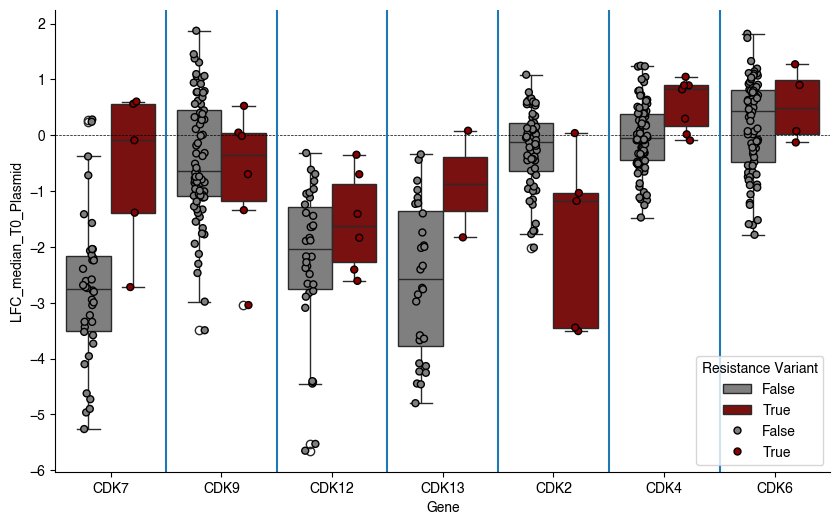

In [387]:
fig, ax = plt.subplots(1,1,figsize=(10,6), sharex=True)

cbe_atp = cbe_atp[cbe_atp['Gene'].isin(['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6'])]

sns.boxplot(data=cbe_atp.drop_duplicates(subset='gRNA_id'), x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax, palette=['tab:grey', 'darkred'])
sns.stripplot(data=cbe_atp.drop_duplicates(subset='gRNA_id'), x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax, dodge=True, edgecolor='black',linewidth=1, palette=['tab:grey', 'darkred'])

ax.axhline(0, linestyle='dashed', color='black', linewidth=0.5)
for i in [.5, 1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(i)
ax.spines[['top', 'right']].set_visible(False)

for gene in ['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(cbe_atp[(cbe_atp['Gene']==gene) & (cbe_atp['Resistance Variant']==True)]['LFC_median_T0_Plasmid'])
    y = list(cbe_atp[(cbe_atp['Gene']==gene) & (cbe_atp['Resistance Variant']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

In [388]:
#then look at resistance variants vs. others in the ATP binding pocket

#need to select these for each condition
LFC_cutoff = 1
FDR_cutoff = 0.1
min_edit = 20

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
subpools = ['SY-5609', 'Subpool1', 'Subpool1', 'Subpool1', 'Subpool2', 'Subpool2', 'Subpool3', 'Subpool3', 'Subpool3']
drugs = [['SY-5609_10nM', 'SY-5609_100nM'],
         ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM'],
         ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM'],
         ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM'],
         ['HQ461', 'BSJ-4-116', 'CDK12-IN-2'],
         ['HQ461', 'BSJ-4-116', 'CDK12-IN-2'],
         ['INX', 'TAGTO'],
         ['PALBO', 'ABEMA', 'RIBO', 'ATIRMO',],
         ['PALBO', 'ABEMA', 'RIBO', 'ATIRMO',]]

abe_hit_list = []
for i, val in enumerate(genes):

    subset_abe = ABE_master_LFC[(ABE_master_LFC['Base_Value']=='DMSO') & (ABE_master_LFC['Screen_ID']==subpools[i])]

    merged = pd.merge(ABE_editing_master, subset_abe, on='gRNA_id')

    merged = merged[merged['Gene']==val]

    drug_list = drugs[i]
    hits = []
    for drug in drug_list:

        l = merged[(merged[f'LFC_median_{drug}_DMSO']>=LFC_cutoff) & (merged[f'FDR_{drug}_DMSO']<FDR_cutoff) & (merged['ATP_binding_pocket_SAV']==True) & (merged['%Reads']>=min_edit) & (merged['Mutation_Class_SAV']=='Missense')]
        for k in list(l['gRNA_id']):
            hits.append(k)


    abe_hit_list.append(hits)

In [389]:
#identify missense edits in atp binding pocket above X% efficiency
abe_atp = abe_merge[(abe_merge['%Reads']>=min_edit) & (abe_merge['ATP_binding_pocket_SAV']==True) & (abe_merge['Mutation_Class_SAV']=='Missense')]

flat_abe_hits = np.unique([item for sublist in abe_hit_list for item in sublist])

abe_atp.loc[abe_atp['gRNA_id'].isin(flat_abe_hits), 'Resistance Variant'] = True
abe_atp.loc[~abe_atp['gRNA_id'].isin(flat_abe_hits), 'Resistance Variant'] = False

CDK7
Ttest_indResult(statistic=-1.4098469320340579, pvalue=0.1628900696563177)
CDK9
Ttest_indResult(statistic=-1.0302446700748658, pvalue=0.3048229265783476)
CDK12
Ttest_indResult(statistic=2.017670326122459, pvalue=0.04769467029536646)
CDK13
Ttest_indResult(statistic=1.7930749172490794, pvalue=0.07836190370652492)
CDK2
Ttest_indResult(statistic=nan, pvalue=nan)
CDK4
Ttest_indResult(statistic=1.1614694848510962, pvalue=0.24794254642067493)
CDK6
Ttest_indResult(statistic=1.4857358259529432, pvalue=0.13984680410508515)


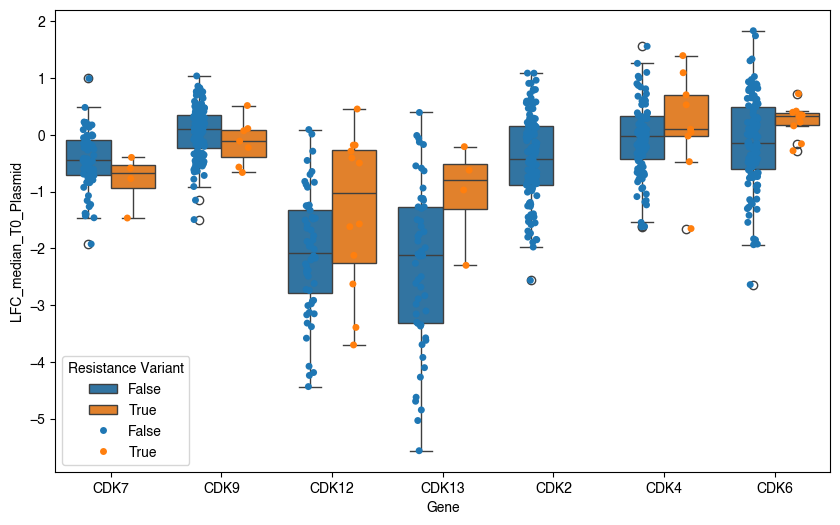

In [390]:
fig, ax = plt.subplots(1,1,figsize=(10,6), sharex=True)
abe_atp = abe_atp[abe_atp['Gene'].isin(['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6'])].drop_duplicates(subset='gRNA_id')
sns.boxplot(data=abe_atp.drop_duplicates(subset='gRNA_id'), x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax)
sns.stripplot(data=abe_atp.drop_duplicates(subset='gRNA_id'), x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax, dodge=True)

for gene in ['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']:
    x = list(abe_atp[(abe_atp['Gene']==gene) & (abe_atp['Resistance Variant']==True)]['LFC_median_T0_Plasmid'])
    y = list(abe_atp[(abe_atp['Gene']==gene) & (abe_atp['Resistance Variant']==False)]['LFC_median_T0_Plasmid'])
    print(gene)
    print(scipy.stats.ttest_ind(x,y))

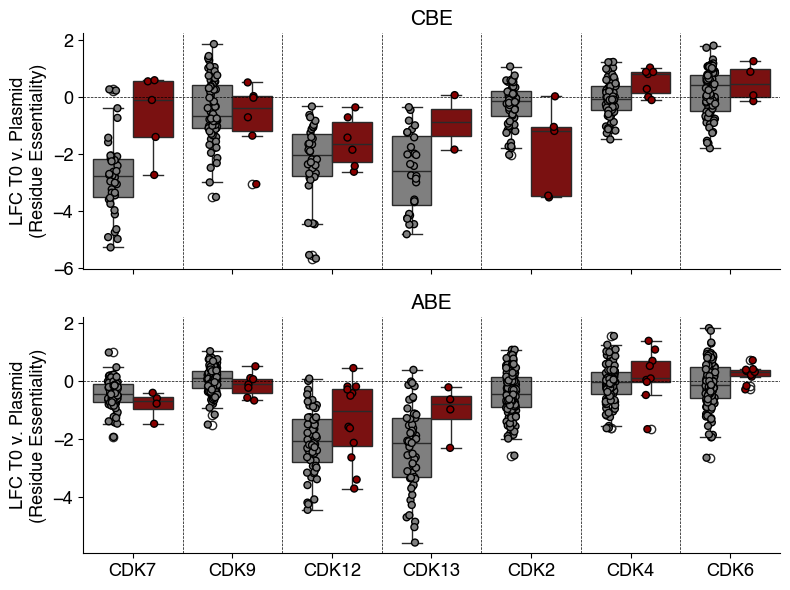

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(8,6), sharex=True)

abe_atp = abe_atp[abe_atp['Gene'].isin(['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6'])].drop_duplicates(subset='gRNA_id')

sns.boxplot(data=abe_atp, x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax[1], palette=['tab:grey', 'darkred'], legend=False)
sns.stripplot(data=abe_atp, x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax[1], dodge=True, edgecolor='black',linewidth=1, palette=['tab:grey', 'darkred'], legend=False)

cbe_atp = cbe_atp[cbe_atp['Gene'].isin(['CDK7', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6'])].drop_duplicates(subset='gRNA_id')

sns.boxplot(data=cbe_atp, x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax[0], palette=['tab:grey', 'darkred'], legend=False)
sns.stripplot(data=cbe_atp, x='Gene', y='LFC_median_T0_Plasmid', hue='Resistance Variant', ax=ax[0], dodge=True, edgecolor='black',linewidth=1, palette=['tab:grey', 'darkred'], legend=False)

ax[0].axhline(0, linestyle='dashed', color='black', linewidth=0.5)
ax[1].axhline(0, linestyle='dashed', color='black', linewidth=0.5)

for i in [.5, 1.5, 2.5, 3.5, 4.5, 5.5]:
    ax[0].axvline(i, linestyle='dashed', color='black', linewidth=0.5)
    ax[1].axvline(i, linestyle='dashed', color='black', linewidth=0.5)
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)

ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[0].set_ylabel('LFC T0 v. Plasmid\n(Residue Essentiality)', fontsize=13)
ax[1].set_ylabel('LFC T0 v. Plasmid\n(Residue Essentiality)', fontsize=13)

ax[1].set_xlabel('')
ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13)

fig.tight_layout()
#fig.savefig('../../figures/atp_binding_essentiality_hits.pdf', transparent=True)

In [ ]:
screen_ids = ['Subpool1', 'Subpool2', 'Subpool3','SY-5609', 'Iterative']

s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID']=='Subpool3')]
s2 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='DMSO') & (CBE_master_LFC['Screen_ID']=='Subpool3')]

md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')
md2 = pd.merge(CBE_editing_master, s2, on='gRNA_id')

assert list(md1['HGVSp'])==list(md2['HGVSp'])
assert list(md1['gRNA_id'])==list(md2['gRNA_id'])

In [169]:
cond = 'PALBO'
l1 = list(md2[(md2[f'LFC_median_{cond}_DMSO']>=0) & (md2[f'FDR_{cond}_DMSO']<.1) & (md2['ATP_binding_pocket_SAV']==True) & (md2['%Reads']>=20)]['gRNA_id'])
l1


['gRNA_CDK4_targ_7657',
 'gRNA_CDK4_targ_7658',
 'gRNA_CDK4_targ_7658',
 'gRNA_CDK6_targ_8145',
 'gRNA_CDK6_targ_8145',
 'gRNA_CDK6_targ_8177',
 'gRNA_CDK6_targ_8177',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426']

In [174]:
md2[(md2[f'LFC_median_{cond}_DMSO']>=0) & (md2[f'FDR_{cond}_DMSO']<.1) & (md2['ATP_binding_pocket_SAV']==True) & (md2['%Reads']>=10)]

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_2000_REP3_T0,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0
7452,gRNA_CDK4_targ_7656,CDK4,49858,E56K,16.647278,56,V57I,57,9.992378,46.869108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7453,gRNA_CDK4_targ_7656,CDK4,49858,V57I,14.611497,57,V57I,57,9.992378,46.869108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7470,gRNA_CDK4_targ_7657,CDK4,161757,E56K,82.879257,56,E56K,56,77.693083,6.579623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7475,gRNA_CDK4_targ_7658,CDK4,174101,E56K,74.742822,56,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7476,gRNA_CDK4_targ_7658,CDK4,174101,R55H,27.825802,55,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7477,gRNA_CDK4_targ_7658,CDK4,174101,E56Q,14.820708,56,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13028,gRNA_CDK6_targ_8145,CDK6,56402,D104N,25.398036,104,D104N,104,23.940640,40.567710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13029,gRNA_CDK6_targ_8145,CDK6,56402,L105F,22.926492,105,D104N,104,23.940640,40.567710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13471,gRNA_CDK6_targ_8177,CDK6,84312,R60H,74.425942,60,R60H_E61K,60,51.114907,5.518787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13472,gRNA_CDK6_targ_8177,CDK6,84312,E61K,60.366259,61,R60H_E61K,60,51.114907,5.518787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
md1.loc[md1['gRNA_id'].isin(l1), 'value'] = True
md1.loc[~md1['gRNA_id'].isin(l1), 'value'] = False


<Axes: xlabel='value', ylabel='LFC_median_T0_Plasmid'>

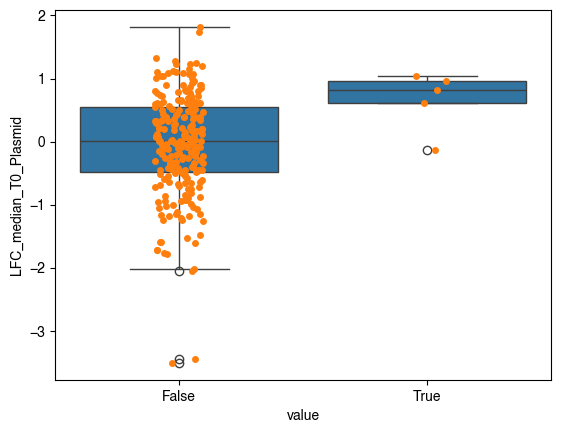

In [176]:
kinase_subset = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=20)]
kinase_subset = kinase_subset.drop_duplicates(subset='gRNA_id')

sns.boxplot(data=kinase_subset, x='value', y='LFC_median_T0_Plasmid')
sns.stripplot(data=kinase_subset, x='value', y='LFC_median_T0_Plasmid')

In [233]:
s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]

md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')

k2 = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=20) & (md1['Mutation_Class_SAV']=='Missense')]
#md1[md1['ATP_binding_pocket_SAV']==True]['KLIFS_index_SAV'])

alphaC = list(range(20,31))
k2.loc[k2['KLIFS_index_SAV'].isin(alphaC), 'value']=True
k2.loc[~k2['KLIFS_index_SAV'].isin(alphaC), 'value']=False

k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0,value
2522,gRNA_CDK19_targ_6521,CDK19,45092,V159I,25.652000,159,V159I,159,16.614921,36.669476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2537,gRNA_CDK19_targ_6522,CDK19,39769,V159I,55.691619,159,V159I,159,50.461415,15.977269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2538,gRNA_CDK19_targ_6522,CDK19,39769,V159L,26.447736,159,V159I,159,50.461415,15.977269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2547,gRNA_CDK19_targ_6526,CDK19,168260,R150K,60.428504,150,R150K,150,49.421134,22.121716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2567,gRNA_CDK19_targ_6529,CDK19,85056,V147I,29.390049,147,W146*,146,41.174050,12.424755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81655,gRNA_CDK6_targ_8455,CDK6,6093,A17V,64.483834,17,A17V,17,59.478090,16.330215,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81669,gRNA_CDK6_targ_8456,CDK6,10615,A17V,79.717381,17,A17V,17,69.769195,0.357984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81687,gRNA_CDK6_targ_8457,CDK6,35512,A17V,69.216040,17,A17V,17,57.374972,5.660059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81714,gRNA_CDK6_targ_8458,CDK6,29601,A17V,46.194385,17,A17V,17,40.826323,26.252491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

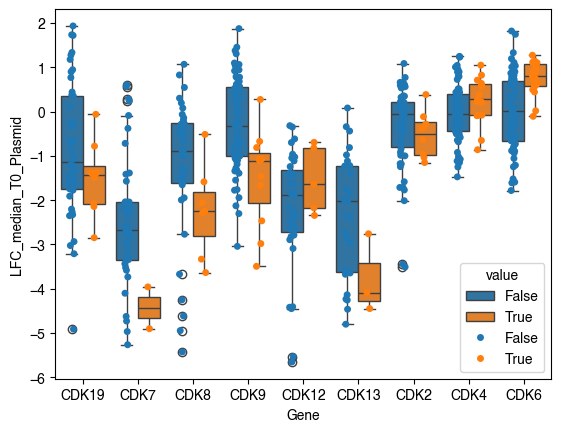

In [234]:
k2 = k2.drop_duplicates(subset='gRNA_id')
sns.boxplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)
sns.stripplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)

In [238]:
g = 'CDK12'
scipy.stats.ttest_ind(k2[(k2['Gene']==g) & (k2['value']==True)]['LFC_median_T0_Plasmid'],k2[(k2['Gene']==g) & (k2['value']==False)]['LFC_median_T0_Plasmid'] )

Ttest_indResult(statistic=1.1182724589829058, pvalue=0.2704705020660068)

In [239]:
s1 = ABE_master_LFC[(ABE_master_LFC['Base_Value']=='Plasmid') & (ABE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]

md1 = pd.merge(ABE_editing_master, s1, on='gRNA_id')

k2 = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=40) & (md1['Mutation_Class_SAV']=='Missense')]
#md1[md1['ATP_binding_pocket_SAV']==True]['KLIFS_index_SAV'])

alphaC = list(range(20,31))
k2.loc[k2['KLIFS_index_SAV'].isin(alphaC), 'value']=True
k2.loc[~k2['KLIFS_index_SAV'].isin(alphaC), 'value']=False

k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,SY-5609_10nM_REP1_T0,SY-5609_10nM_REP2_T0,SY-5609_10nM_REP3_T0,LFC_median_SY-5609_100nM_T0,LFC_median_SY-5609_10nM_T0,LFC_avg_SY-5609_100nM_T0,LFC_avg_SY-5609_10nM_T0,FDR_SY-5609_100nM_T0,FDR_SY-5609_10nM_T0,value
1726,gRNA_CDK19_targ_6521,CDK19,50912,V159A,84.394642,159,V159A_M160T,159,47.788341,14.532920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1730,gRNA_CDK19_targ_6522,CDK19,66168,V159A,87.187160,159,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1731,gRNA_CDK19_targ_6522,CDK19,66168,L158P,67.212248,158,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1737,gRNA_CDK19_targ_6523,CDK19,16573,I157T,43.878598,157,I157T,157,42.454595,54.371568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1748,gRNA_CDK19_targ_6527,CDK19,262662,V147A,65.890765,147,V147A,147,35.146690,10.053605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52431,gRNA_CDK6_targ_8455,CDK6,1530,A17V,61.045752,17,A17V,17,50.849673,28.300654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52436,gRNA_CDK6_targ_8456,CDK6,2156,E18G,77.319109,18,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52437,gRNA_CDK6_targ_8456,CDK6,2156,I19V,68.506494,19,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52441,gRNA_CDK6_targ_8457,CDK6,7437,E18G,57.590426,18,E18G,18,50.221864,21.527498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [ ]:
g = 'CDK4'
scipy.stats.ttest_ind(k2[(k2['Gene']==g) & (k2['value']==True)]['LFC_median_T0_Plasmid'],k2[(k2['Gene']==g) & (k2['value']==False)]['LFC_median_T0_Plasmid'] )

Ttest_indResult(statistic=0.6345666569482504, pvalue=0.5278095430934957)

<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

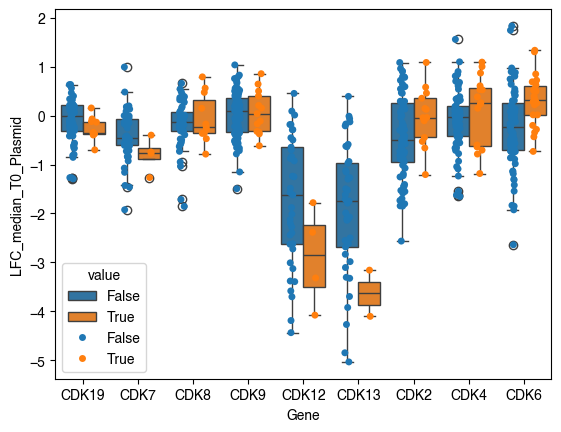

In [223]:
k2 = k2.drop_duplicates(subset='gRNA_id')
sns.boxplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)
sns.stripplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)

In [221]:
k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,SY-5609_10nM_REP1_T0,SY-5609_10nM_REP2_T0,SY-5609_10nM_REP3_T0,LFC_median_SY-5609_100nM_T0,LFC_median_SY-5609_10nM_T0,LFC_avg_SY-5609_100nM_T0,LFC_avg_SY-5609_10nM_T0,FDR_SY-5609_100nM_T0,FDR_SY-5609_10nM_T0,value
1712,gRNA_CDK19_targ_6519,CDK19,113946,V159A,26.860092,159,M160T,160,24.035947,25.375178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1721,gRNA_CDK19_targ_6520,CDK19,121547,V159A,37.499074,159,M160T,160,37.931006,18.517117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1726,gRNA_CDK19_targ_6521,CDK19,50912,V159A,84.394642,159,V159A_M160T,159,47.788341,14.532920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1730,gRNA_CDK19_targ_6522,CDK19,66168,V159A,87.187160,159,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1737,gRNA_CDK19_targ_6523,CDK19,16573,I157T,43.878598,157,I157T,157,42.454595,54.371568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52418,gRNA_CDK6_targ_8454,CDK6,4893,I19V,65.849172,19,I19V,19,42.489270,28.305743,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52431,gRNA_CDK6_targ_8455,CDK6,1530,A17V,61.045752,17,A17V,17,50.849673,28.300654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52436,gRNA_CDK6_targ_8456,CDK6,2156,E18G,77.319109,18,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52441,gRNA_CDK6_targ_8457,CDK6,7437,E18G,57.590426,18,E18G,18,50.221864,21.527498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [216]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

KLIFS[:50]

,KLIFS_idx,CDK7,CDK7_seq,CDK8,CDK8_seq,CDK19,CDK19_seq,CDK9,CDK9_seq,CDK12,CDK12_seq,CDK13,CDK13_seq,CDK2,CDK2_seq,CDK4,CDK4_seq,CDK6,CDK6_seq
0,I:1,16.0,D,25.0,C,25.0,C,23.0,A,731.0,G,709.0,G,8.0,E,10.0,A,17.0,A
1,I:2,17.0,F,26.0,K,26.0,K,24.0,K,732.0,I,710.0,I,9.0,K,11.0,E,18.0,E
2,I:3,18.0,L,27.0,V,27.0,V,25.0,I,733.0,I,711.0,I,10.0,I,12.0,I,19.0,I
3,g.l:4,19.0,G,28.0,G,28.0,G,26.0,G,734.0,G,712.0,G,11.0,G,13.0,G,20.0,G
4,g.l:5,20.0,E,29.0,R,29.0,R,27.0,Q,735.0,E,713.0,E,12.0,E,14.0,V,21.0,E
5,g.l:6,21.0,G,30.0,G,30.0,G,28.0,G,736.0,G,714.0,G,13.0,G,15.0,G,22.0,G
6,g.l:7,22.0,Q,31.0,T,31.0,T,29.0,T,737.0,T,715.0,T,14.0,T,16.0,A,23.0,A
7,g.l:8,23.0,F,32.0,Y,32.0,Y,30.0,F,738.0,Y,716.0,Y,15.0,Y,17.0,Y,24.0,Y
8,g.l:9,24.0,A,33.0,G,33.0,G,31.0,G,739.0,G,717.0,G,16.0,G,18.0,G,25.0,G
9,II:10,25.0,T,34.0,H,34.0,H,32.0,E,740.0,Q,718.0,Q,17.0,V,19.0,T,26.0,K


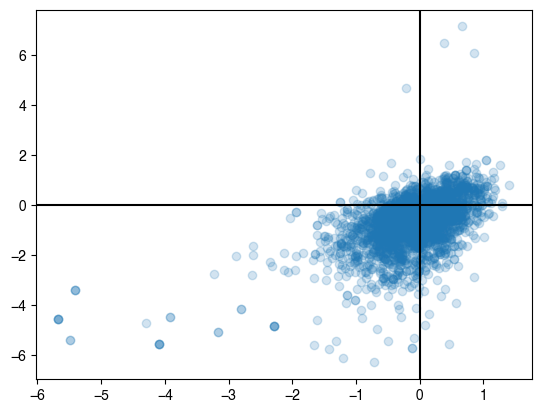

In [85]:
m3 = md1[md1['%Reads']>=40]
plt.scatter(m3['LFC_median_DMSO_Plasmid'], m3['LFC_median_KI-CDK9d-32_1000nM_Plasmid'], alpha=.2)
plt.axvline(0, color='black')
plt.axhline(0, color='black')

In [71]:
s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')


md2 = md1.drop_duplicates(subset=['gRNA_id', 'Top_HGVSp'])
#md1[md1['Nonsense_perc']>=50] #[['LFC_median_T0_Plasmid']]


#md1.loc[]
min_nonsense = 20
md2.loc[md2['Nonsense_perc']>=min_nonsense, 'Nonsense_Guide'] = True
md2.loc[md2['Nonsense_perc']<min_nonsense, 'Nonsense_Guide'] = False

In [70]:
md2[md2['Nonsense_Guide']==True]

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0,Nonsense_Guide
2222,gRNA_CDK19_targ_6488,CDK19,87805,W218*,62.362052,218,W218*,218,49.599681,26.354991,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2227,gRNA_CDK19_targ_6489,CDK19,41017,W218*,64.263598,218,W218*,218,32.615745,9.705732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2239,gRNA_CDK19_targ_6490,CDK19,30792,W218*,59.642115,218,W218*,218,31.319823,16.091842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2254,gRNA_CDK19_targ_6491,CDK19,58486,W218*,72.154020,218,W218*,218,65.909790,13.685326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2329,gRNA_CDK19_targ_6501,CDK19,288044,W198*,69.763300,198,W198*,198,68.624585,17.825055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81823,gRNA_CDK6_targ_8465,CDK6,115034,Q12*,74.150251,12,Q12*,12,28.442026,13.402994,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81833,gRNA_CDK6_targ_8466,CDK6,55072,Q11*,82.953225,11,Q11*_Q12*,11,31.427949,2.002833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81851,gRNA_CDK6_targ_8467,CDK6,111221,Q11*,70.090181,11,Q11*_Q12*,11,42.730240,10.621196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81867,gRNA_CDK6_targ_8468,CDK6,50289,Q11*,75.738233,11,Q11*,11,40.064428,3.473921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

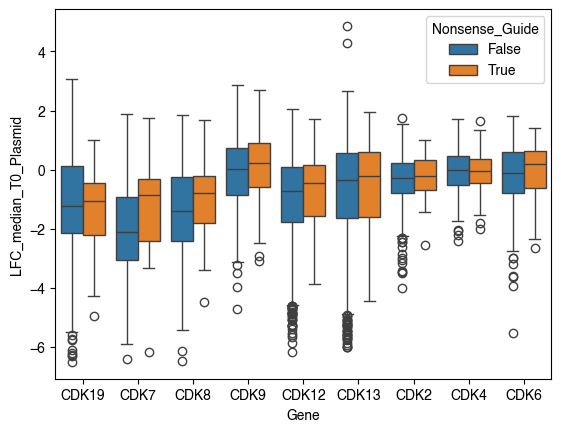

In [74]:
sns.boxplot(data=md2, x='Gene', y='LFC_median_T0_Plasmid', hue='Nonsense_Guide')